# Load Data

In [4]:
import pandas as pd

# Load the historical quotes CSV file
df = pd.read_csv('HistoricalQuotes.csv')
print(df.head())

         Date  Close/Last     Volume      Open      High       Low
0  02/28/2020     $273.36  106721200   $257.26   $278.41   $256.37
1  02/27/2020     $273.52   80151380    $281.1      $286   $272.96
2  02/26/2020     $292.65   49678430   $286.53   $297.88    $286.5
3  02/25/2020     $288.08   57668360   $300.95   $302.53   $286.13
4  02/24/2020     $298.18   55548830   $297.26   $304.18   $289.23


# Data Preprocessing 

In [5]:
# ── Phase 2: Preprocessing ───────────────────
# Fix column name spaces
df.columns = df.columns.str.strip()

# Remove $ signs and convert to numeric
for col in ['Close/Last', 'Open', 'High', 'Low']:
    df[col] = df[col].str.replace('$', '', regex=False).astype(float)

df['Volume'] = df['Volume'].astype(float)

# Convert Date and sort oldest → newest
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Check missing values
print("Missing values:", df.isnull().sum().sum())
print("Shape:", df.shape)
print(df.dtypes)

Missing values: 0
Shape: (2518, 6)
Date          datetime64[ns]
Close/Last           float64
Volume               float64
Open                 float64
High                 float64
Low                  float64
dtype: object


In [6]:
from sklearn.preprocessing import MinMaxScaler

# Target → next day closing price
df['Target'] = df['Close/Last'].shift(-1)
df = df.dropna().reset_index(drop=True)

# Normalize features
scaler = MinMaxScaler()
features = ['Close/Last', 'Open', 'High', 'Low', 'Volume']
df[features] = scaler.fit_transform(df[features])

print(f"Clean data shape: {df.shape}")
print(df.head())

Clean data shape: (2517, 7)
        Date  Close/Last    Volume      Open      High       Low   Target
0 2010-03-01    0.000067  0.279219  0.000000  0.000000  0.003004  29.8357
1 2010-03-02    0.000000  0.288472  0.002022  0.000638  0.004113  29.9043
2 2010-03-03    0.000231  0.180643  0.001543  0.000177  0.004210  30.1014
3 2010-03-04    0.000894  0.173428  0.001707  0.000681  0.004544  31.2786
4 2010-03-05    0.004852  0.472832  0.004445  0.004891  0.007451  31.2971


# EDA Visualizations

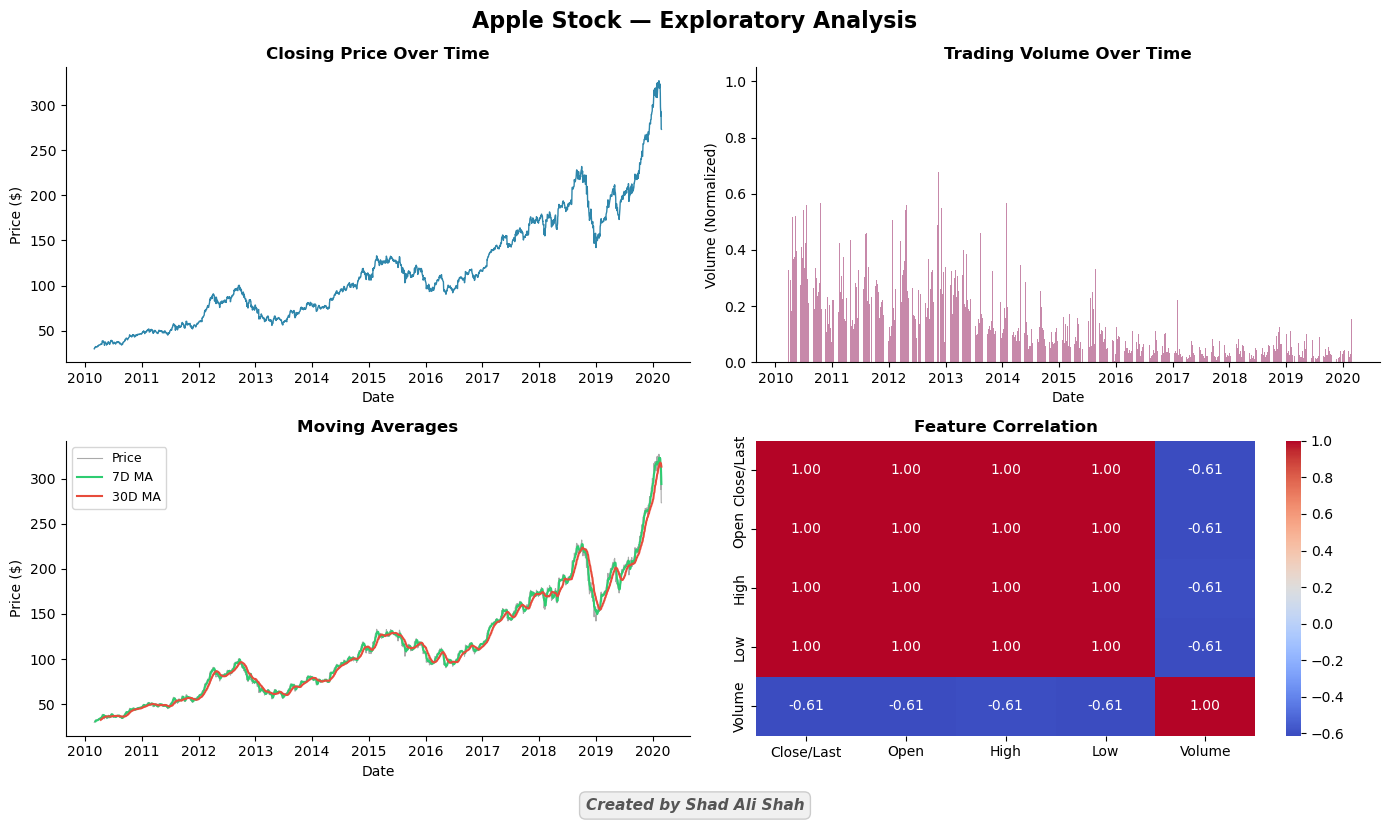

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Phase 3: EDA Visualizations ──────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Apple Stock — Exploratory Analysis',
             fontsize=16, fontweight='bold')

# Chart 1 — Closing Price Over Time
axes[0,0].plot(df['Date'], df['Target'], color='#2E86AB', linewidth=1)
axes[0,0].set_title('Closing Price Over Time', fontweight='bold')
axes[0,0].set_xlabel('Date'); axes[0,0].set_ylabel('Price ($)')
axes[0,0].spines[['top','right']].set_visible(False)

# Chart 2 — Volume Over Time
axes[0,1].bar(df['Date'], df['Volume'], color='#A23B72', alpha=0.6, width=1)
axes[0,1].set_title('Trading Volume Over Time', fontweight='bold')
axes[0,1].set_xlabel('Date'); axes[0,1].set_ylabel('Volume (Normalized)')
axes[0,1].spines[['top','right']].set_visible(False)

# Chart 3 — Moving Averages
axes[1,0].plot(df['Date'], df['Target'], color='#AAAAAA', linewidth=0.8, label='Price')
axes[1,0].plot(df['Date'], df['Target'].rolling(7).mean(),  color='#2ECC71', linewidth=1.5, label='7D MA')
axes[1,0].plot(df['Date'], df['Target'].rolling(30).mean(), color='#E74C3C', linewidth=1.5, label='30D MA')
axes[1,0].set_title('Moving Averages', fontweight='bold')
axes[1,0].set_xlabel('Date'); axes[1,0].set_ylabel('Price ($)')
axes[1,0].legend(fontsize=9)
axes[1,0].spines[['top','right']].set_visible(False)

# Chart 4 — Correlation Heatmap
corr = df[['Close/Last','Open','High','Low','Volume']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1,1], cbar=True,
            annot_kws={'size':10})
axes[1,1].set_title('Feature Correlation', fontweight='bold')

fig.text(0.5, -0.02, 'Created by Shad Ali Shah',
         color='#555555', fontsize=11, ha='center',
         style='italic', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4',
                   facecolor='#F0F0F0', edgecolor='#CCCCCC'))

plt.tight_layout()
plt.savefig('stock_eda.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Train/Test Split

In [8]:
# ── Phase 4: Train/Test Split ─────────────────
features = ['Close/Last', 'Open', 'High', 'Low', 'Volume']
X = df[features].values
y = df['Target'].values

# 80/20 split — NO shuffling (time series order must stay)
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Total  : {len(X)} days")
print(f"Train  : {len(X_train)} days (80%)")
print(f"Test   : {len(X_test)} days (20%)")

Total  : 2517 days
Train  : 2013 days (80%)
Test   : 504 days (20%)


## Chek the Performance  of Linear Regression

In [9]:
# ── Phase 5: Linear Regression ───────────────
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("=" * 40)
print("   LINEAR REGRESSION RESULTS")
print("=" * 40)
print(f"  MAE  : ${mae_lr:.2f}")
print(f"  RMSE : ${rmse_lr:.2f}")
print(f"  R²   : {r2_lr:.4f}")
print("=" * 40)

   LINEAR REGRESSION RESULTS
  MAE  : $2.64
  RMSE : $3.71
  R²   : 0.9920


## Now we move to LSTM model to check the performance of this model

In [10]:
# ── Phase 6: LSTM ─────────────────────────────
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

# Reshape for LSTM → (samples, timesteps, features)
X_train_lstm = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_lstm  = X_test.reshape(X_test.shape[0],  1, X_test.shape[1])

# Build LSTM
model = Sequential([
    Input(shape=(1, X_train.shape[1])),
    LSTM(50, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

# EarlyStopping → stops when model stops improving
early_stop = EarlyStopping(monitor='loss', patience=10, verbose=1)
model.fit(X_train_lstm, y_train, epochs=200, batch_size=32,
          callbacks=[early_stop], verbose=0)

# Evaluate
y_pred_lstm = model.predict(X_test_lstm).flatten()

mae_lstm  = mean_absolute_error(y_test, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
r2_lstm   = r2_score(y_test, y_pred_lstm)

print("=" * 40)
print("       LSTM RESULTS")
print("=" * 40)
print(f"  MAE  : ${mae_lstm:.2f}")
print(f"  RMSE : ${rmse_lstm:.2f}")
print(f"  R²   : {r2_lstm:.4f}")
print("=" * 40)

c:\Users\PMLS\miniconda3\envs\dl\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Epoch 122: early stopping
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
       LSTM RESULTS
  MAE  : $6.32
  RMSE : $8.84
  R²   : 0.9550


The RMSE of LSTM model is High than Linear Regression so we conclude that the best model is Linear regression so we predict the future stock prices on the basis of Linear regressions

# Print Future Predicted Prices on the basis Linear Model

In [17]:
# ── Future Price Prediction (Linear Regression) ──
future_days = 30
last_data = X_test[-future_days:]

future_pred = lr.predict(last_data)
future_dates = pd.date_range(
    start=df['Date'].iloc[-1], periods=future_days+1, freq='B')[1:]

# Print results
print("=" * 35)
print("  FUTURE STOCK PRICE PREDICTIONS")
print("=" * 35)
for date, price in zip(future_dates, future_pred):
    print(f"  {date.strftime('%Y-%m-%d')}  →  ${price:.2f}")
print("=" * 35)

  FUTURE STOCK PRICE PREDICTIONS
  2020-02-28  →  $311.68
  2020-03-02  →  $315.09
  2020-03-03  →  $318.54
  2020-03-04  →  $316.73
  2020-03-05  →  $317.82
  2020-03-06  →  $318.98
  2020-03-09  →  $318.72
  2020-03-10  →  $308.81
  2020-03-11  →  $317.74
  2020-03-12  →  $324.51
  2020-03-13  →  $323.68
  2020-03-16  →  $310.20
  2020-03-17  →  $309.23
  2020-03-18  →  $318.77
  2020-03-19  →  $321.42
  2020-03-20  →  $324.93
  2020-03-23  →  $320.02
  2020-03-24  →  $321.54
  2020-03-25  →  $319.68
  2020-03-26  →  $327.18
  2020-03-27  →  $324.90
  2020-03-30  →  $324.83
  2020-03-31  →  $319.00
  2020-04-01  →  $323.72
  2020-04-02  →  $320.45
  2020-04-03  →  $313.31
  2020-04-06  →  $298.36
  2020-04-07  →  $288.77
  2020-04-08  →  $293.51
  2020-04-09  →  $274.59


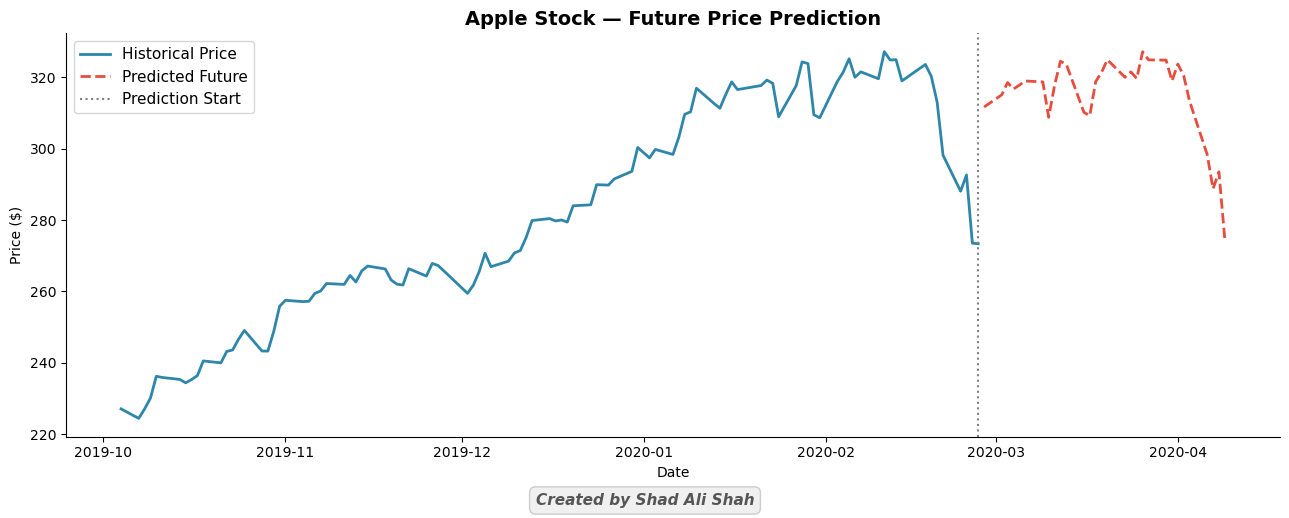

In [18]:
# ── Plot Future Predictions ───────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df['Date'].iloc[-100:], df['Target'].iloc[-100:],
        color='#2E86AB', linewidth=2, label='Historical Price')
ax.plot(future_dates, future_pred,
        color='#E74C3C', linewidth=2,
        linestyle='--', label='Predicted Future')

ax.axvline(df['Date'].iloc[-1], color='gray',
           linestyle=':', linewidth=1.5, label='Prediction Start')
ax.set_title('Apple Stock — Future Price Prediction',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Price ($)')
ax.legend(fontsize=11)
ax.spines[['top','right']].set_visible(False)

fig.text(0.5, -0.02, 'Created by Shad Ali Shah',
         color='#555555', fontsize=11, ha='center',
         style='italic', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4',
                   facecolor='#F0F0F0', edgecolor='#CCCCCC'))

plt.tight_layout()
plt.savefig('future_prediction.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

The blue line shows Historical stock prices and red line shows the future or predicted stock prices.